In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix  
import pathlib
import PIL
import cv2

from tensorflow.keras import models, layers 

'''
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
'''

I0000 00:00:1780116178.852703   37302 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780116178.853154   37302 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780116178.894347   37302 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780116179.994326   37302 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

'\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D\n'

In [3]:
# 1. feed-forward NN - Multiclass Image Classification on MNIST 

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#plt.matshow(x_train[1]), x_train.shape --> (60000, 28, 28)

'''
norm_layer = layers.Normalization()
norm_layer.adapt(x_train)
'''
model = models.Sequential([
    layers.Input(shape=(28,28)), #ghost layer to map inputs, created by arg input_shape=(28, 28) of first layer automatically
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(units=128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(units=10, activation="softmax") #10 classes
])

# sparse_categorical_crossentropy loss since y_target variables are integers 
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=2, batch_size=32)
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_acc}")
model.summary() # None --> bach size, each row for each sample 

Epoch 1/2


E0000 00:00:1780109514.611139   32133 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9139 - loss: 0.2967
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9571 - loss: 0.1435
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9705 - loss: 0.1007


test_loss : 0.10065779834985733, test_accuracy : 0.9704999923706055


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [35]:
y_pred_0 = np.argmax(model.predict(x_test[0:1])) # max probability arg/label # shape --> (1, 28,28), x_test[0] --> (28,28)
y_test_0 = y_test[0]
print(y_pred_0, y_test_0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
7 7


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]


<Axes: >

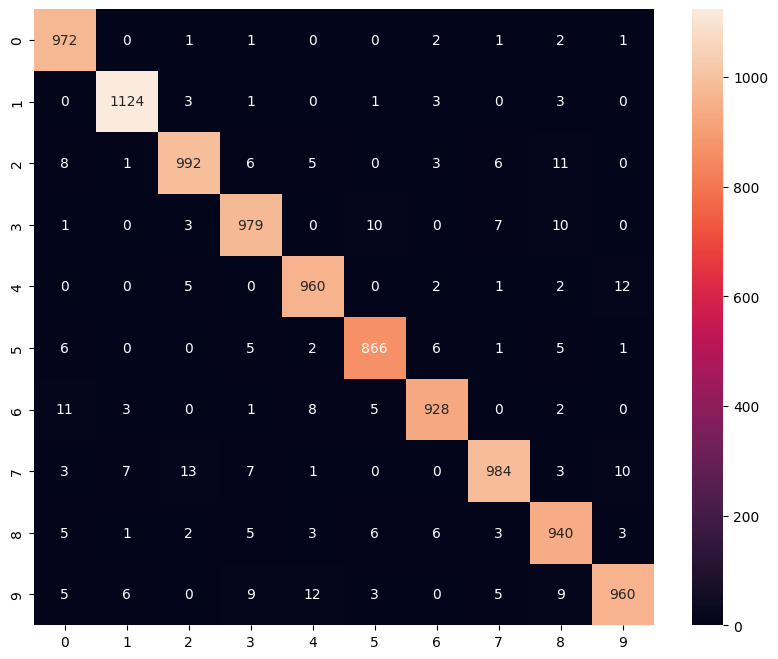

In [20]:
#y_pred = [np.argmax(i).item() for i in model.predict(x_test)]
y_pred = np.argmax(model.predict(x_test), axis=1)
print(y_pred)
print(y_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')

In [47]:
# 2, CNN - Multiclass Image Classification on CIFAR10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, y_train = x_train[:10000], y_train[:10000]
x_test, y_test = x_test[:2000], y_test[:2000]
y_test[0]

array([3], dtype=uint8)

In [48]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_test[0] # to demonstrate using catgorical cross entopy loss for one hot encoded y target

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [53]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)), #batch will be another dimension while training
    layers.Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(1,1), padding='same'), # same --> paddding=1 so output dim are same, valid --> padding=0
    layers.Flatten(),
    layers.Dense(units=128, activation="relu"),
    layers.Dense(units=10, activation="softmax")
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_acc}")
model.summary()

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.2507 - loss: 2.2007 - val_accuracy: 0.3580 - val_loss: 1.7555
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.4197 - loss: 1.5961 - val_accuracy: 0.4540 - val_loss: 1.5311
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4540 - loss: 1.5311


test_loss : 1.5310817956924438, test_accuracy : 0.45399999618530273


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,589,856 (48.03 MB)

 Trainable params: 4,196,618 (16.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,393,238 (32.02 MB)

In [62]:
cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Example usage with class index 3
print(cifar10_classes[np.argmax(model.predict(x_test[0:1]))])
print(cifar10_classes[int(y_test[0][0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
cat
airplane


In [13]:
# classiification of flowers and data augmentation
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file(fname="flowers", origin=dataset_url, untar=True)
data_dir = pathlib.Path(archive) / "flower_photos"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,  
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
)

class_names = train_ds.class_names 

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = models.Sequential([
        layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
])

model = models.Sequential([
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(len(class_names)),
])

# loss="sparse_categorical_crossentropy" expects probabilities from softmax, Relu returns logits 
model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
model.fit(train_ds, validation_data=test_ds, epochs=5)
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_accuracy}")
model.summary()

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - accuracy: 0.4278 - loss: 1.3415 - val_accuracy: 0.5218 - val_loss: 1.1158
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.5681 - loss: 1.0683 - val_accuracy: 0.5272 - val_loss: 1.1988
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.6165 - loss: 0.9847 - val_accuracy: 0.5395 - val_loss: 1.2023
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.6509 - loss: 0.8985 - val_accuracy: 0.6485 - val_loss: 0.9172
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.6737 - loss: 0.8456 - val_accuracy: 0.6567 - val_loss: 0.8964
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6567 - loss: 0.8964

	est_loss : 0.8964494466781616, test_accuracy : 0.6566757559776306


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,967,857 (45.65 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,978,572 (30.44 MB)

In [21]:
test_iterator = iter(test_ds)
x_batch, y_batch = next(test_iterator)

x_test_0 = x_batch[0:1]  # Shape is (1, 180, 180, 3)
y_test_0 = class_names[y_batch[0].numpy()]  
y_pred_0 = class_names[np.argmax(model.predict(x_test_0))]
print(y_test_0, y_pred_0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
dandelion daisy
